In [16]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from pathlib import Path
import mcstasscript as ms
from scipy.optimize import curve_fit  

Pole cut: excluding |latitude| > 85.0 deg (last 5.0 deg near each pole)


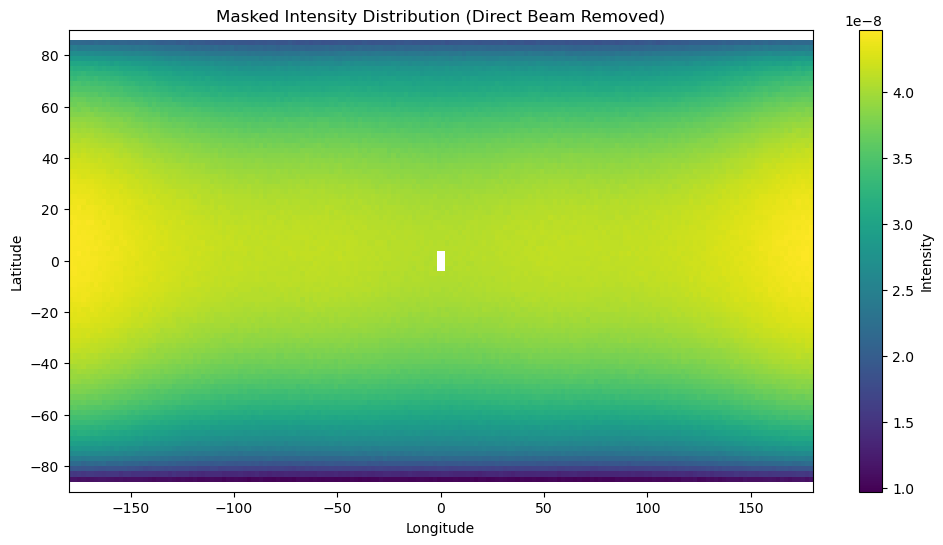

/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_43348/862494956.py:96: RuntimeWarning: Mean of empty slice
  meridian_cut = np.nanmean(meridian_band, axis=1)
/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_43348/862494956.py:100: RuntimeWarning: invalid value encountered in divide
  np.sqrt(np.nansum(meridian_band_err**2, axis=1)) / meridian_valid_counts,


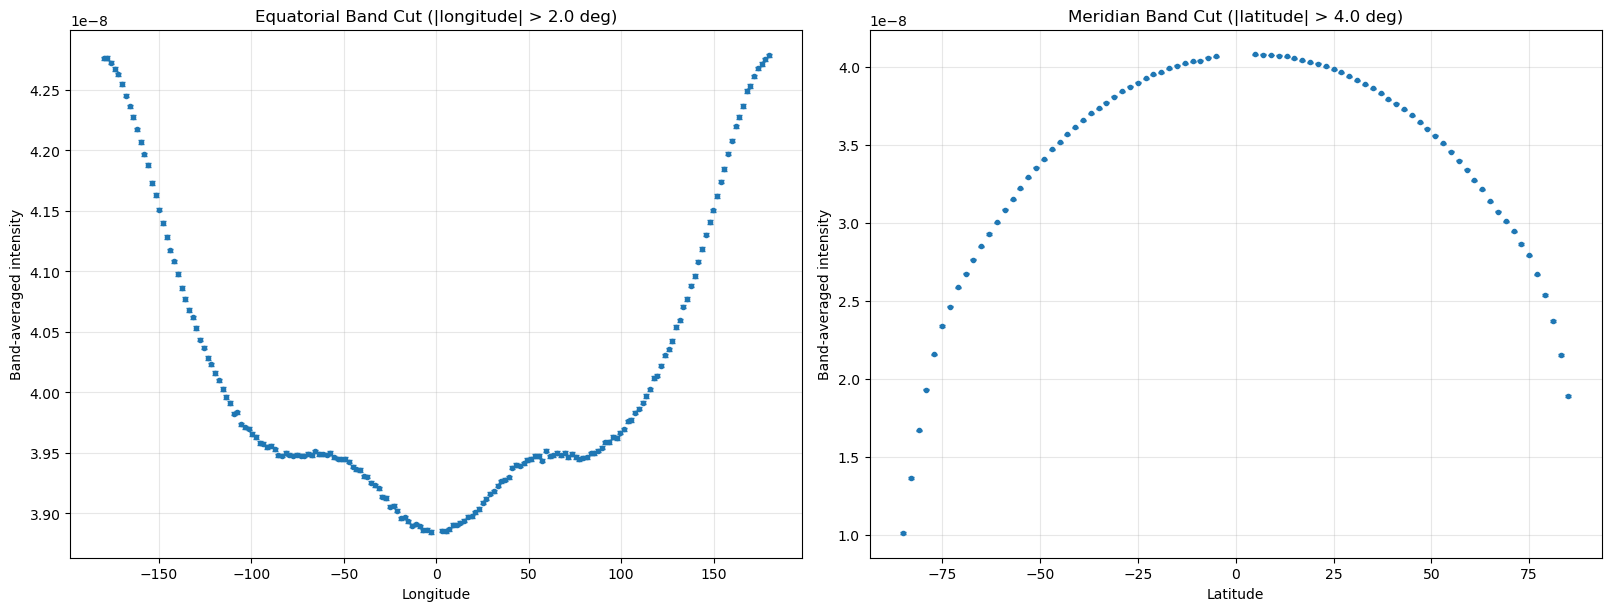

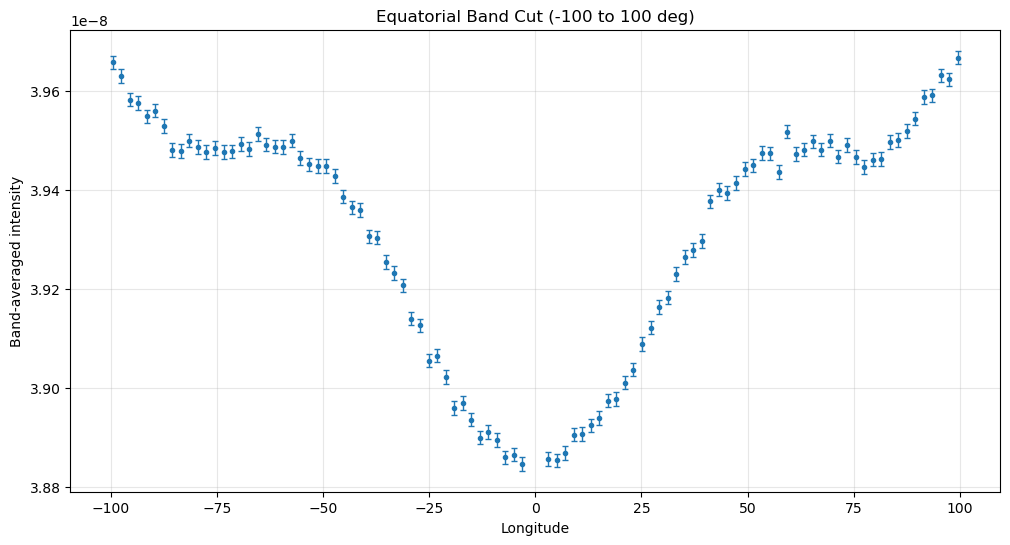

In [17]:
sphere_mon = ms.load_data("/Users/christian/Documents/Study/bachelor_project/geometry_optimization/cylinder_instrument/1p4to2p3_1e10/6")[0]  # adjust index if needed
meta = sphere_mon.metadata
hits = sphere_mon.Intensity
hits_err = sphere_mon.Error
xmin, xmax, ymin, ymax = meta.limits
extent = [xmin, xmax, ymin, ymax]
Hmc = np.array(hits, copy=True)
Hmc_err = np.array(hits_err, copy=True)

# Ensure the array layout is (latitude, longitude).
if hasattr(meta, "dimension") and Hmc.shape == (meta.dimension[0], meta.dimension[1]):
    Hmc = Hmc.T
    Hmc_err = Hmc_err.T

pole_cut_deg = 5.0
lat_centers = np.linspace(ymin + 0.5 * (ymax - ymin) / Hmc.shape[0], ymax - 0.5 * (ymax - ymin) / Hmc.shape[0], Hmc.shape[0])
cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
pole_mask = np.abs(lat_centers) <= (90.0 - pole_cut_deg)
print(f"Pole cut: excluding |latitude| > {90.0 - pole_cut_deg:.1f} deg (last {pole_cut_deg:.1f} deg near each pole)")

safe_cos = np.where(np.abs(cos_correction) > 0, cos_correction, np.nan)
Hmc_corrected = Hmc / safe_cos
Hmc_err_corrected = Hmc_err / safe_cos
Hmc_corrected = np.where(pole_mask[:, np.newaxis], Hmc_corrected, np.nan)
Hmc_err_corrected = np.where(pole_mask[:, np.newaxis], Hmc_err_corrected, np.nan)

# ------------------------------------------------------------
# Define angular grid
# ------------------------------------------------------------
lon = np.linspace(xmin, xmax, Hmc_corrected.shape[1])
lat = lat_centers
Lon, Lat = np.meshgrid(lon, lat)

# ------------------------------------------------------------
# Beam mask (from your calibration)
# ------------------------------------------------------------
beam_lon_halfwidth_deg = 2.0
beam_lat_halfwidth_deg = 4.0

beam_mask = (
    (np.abs(Lon) <= beam_lon_halfwidth_deg) &
    (np.abs(Lat) <= beam_lat_halfwidth_deg)
)

# Combine with pole mask
full_mask = pole_mask[:, np.newaxis] & (~beam_mask)

# ------------------------------------------------------------
# Apply mask to corrected data
# ------------------------------------------------------------
Hmc_masked = np.where(full_mask, Hmc_corrected, np.nan)
Hmc_err_masked = np.where(full_mask, Hmc_err_corrected, np.nan)

# ------------------------------------------------------------
# Plot masked map
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))
plt.imshow(Hmc_masked, extent=extent, origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='Intensity')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Masked Intensity Distribution (Direct Beam Removed)')
plt.show()

# ------------------------------------------------------------
# Equator band cut (mask-aware)
# ------------------------------------------------------------
equator_band_halfwidth = 50.0  # degrees
equator_band_mask = np.abs(lat) <= equator_band_halfwidth

equator_band = Hmc_masked[equator_band_mask, :]
equator_band_err = Hmc_err_masked[equator_band_mask, :]

equator_cut = np.nanmean(equator_band, axis=0)
valid_counts = np.sum(~np.isnan(equator_band), axis=0)
equator_cut_err = np.where(
    valid_counts > 0,
    np.sqrt(np.nansum(equator_band_err**2, axis=0)) / valid_counts,
    np.nan,
)
valid_cols = (valid_counts > 0) & (np.abs(lon) > beam_lon_halfwidth_deg)

lon_plot = lon[valid_cols]
equator_cut_plot = equator_cut[valid_cols]
equator_cut_err_plot = equator_cut_err[valid_cols]

# ------------------------------------------------------------
# Meridian band cut (mask-aware)
# ------------------------------------------------------------
meridian_band_halfwidth = 10.0  # degrees around longitude = 0
meridian_band_mask = np.abs(lon) <= meridian_band_halfwidth

meridian_band = Hmc_masked[:, meridian_band_mask]
meridian_band_err = Hmc_err_masked[:, meridian_band_mask]

meridian_cut = np.nanmean(meridian_band, axis=1)
meridian_valid_counts = np.sum(~np.isnan(meridian_band), axis=1)
meridian_cut_err = np.where(
    meridian_valid_counts > 0,
    np.sqrt(np.nansum(meridian_band_err**2, axis=1)) / meridian_valid_counts,
    np.nan,
)
valid_rows = (meridian_valid_counts > 0) & (np.abs(lat) > beam_lat_halfwidth_deg)

lat_plot = lat[valid_rows]
meridian_cut_plot = meridian_cut[valid_rows]
meridian_cut_err_plot = meridian_cut_err[valid_rows]

fig, axs = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

axs[0].errorbar(lon_plot, equator_cut_plot, yerr=equator_cut_err_plot,
                fmt='o', ms=3, elinewidth=1, capsize=2)
axs[0].set_xlabel('Longitude')
axs[0].set_ylabel('Band-averaged intensity')
axs[0].set_title(f'Equatorial Band Cut (|longitude| > {beam_lon_halfwidth_deg:.1f} deg)')
axs[0].grid(True, alpha=0.3)

axs[1].errorbar(lat_plot, meridian_cut_plot, yerr=meridian_cut_err_plot,
                fmt='o', ms=3, elinewidth=1, capsize=2)
axs[1].set_xlabel('Latitude')
axs[1].set_ylabel('Band-averaged intensity')
axs[1].set_title(f'Meridian Band Cut (|latitude| > {beam_lat_halfwidth_deg:.1f} deg)')
axs[1].grid(True, alpha=0.3)

plt.show()

# ------------------------------------------------------------
# Zoomed equator band cut from -100 to 100 degrees
# ------------------------------------------------------------
equator_zoom_mask = (lon_plot >= -100.0) & (lon_plot <= 100.0)

plt.figure(figsize=(12, 6))
plt.errorbar(
    lon_plot[equator_zoom_mask],
    equator_cut_plot[equator_zoom_mask],
    yerr=equator_cut_err_plot[equator_zoom_mask],
    fmt='o',
    ms=3,
    elinewidth=1,
    capsize=2,
)
plt.xlabel('Longitude')
plt.ylabel('Band-averaged intensity')
plt.title('Equatorial Band Cut (-100 to 100 deg)')
plt.grid(True, alpha=0.3)
plt.show()


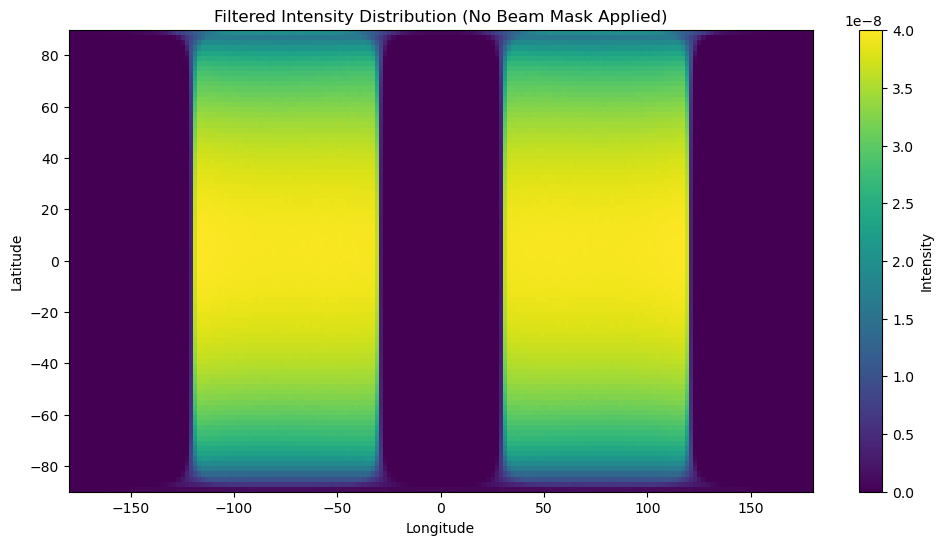

Low outlier cut: removing equator-cut points below 3.543e-08


/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_43348/387296082.py:46: RuntimeWarning: Mean of empty slice
  equator_cut = np.nanmean(equator_band_nonzero, axis=0)
/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_43348/387296082.py:50: RuntimeWarning: invalid value encountered in divide
  np.sqrt(np.nansum(equator_band_err_nonzero**2, axis=0)) / valid_counts,


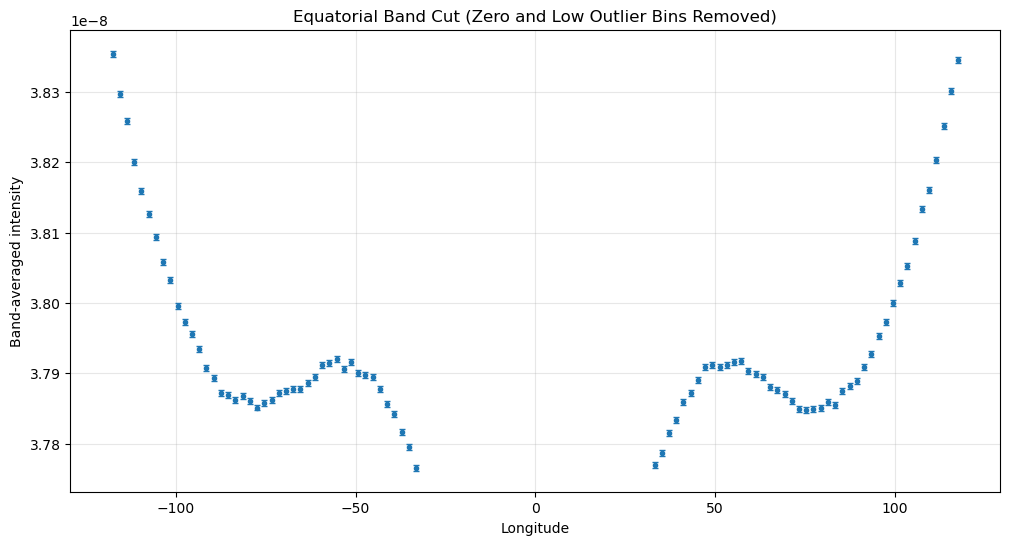

In [18]:
# Plot filtered McStas output without applying a beam mask.
# Zero bins from the McStas angular filter are removed from the equator cut.
sphere_mon = ms.load_data('/Users/christian/Documents/Study/bachelor_project/geometry_optimization/cylinder_instrument/nolid_1e11')[0]  # adjust path/index if needed
sphere_mon = ms.load_data('/Users/christian/Documents/Study/bachelor_project/geometry_optimization/cylinder_instrument/1p75to1p85_1e11/2')[0]  # adjust path/index if needed
meta = sphere_mon.metadata
Hmc = np.array(sphere_mon.Intensity, copy=True)
Hmc_err = np.array(sphere_mon.Error, copy=True)
xmin, xmax, ymin, ymax = meta.limits
extent = [xmin, xmax, ymin, ymax]

if hasattr(meta, 'dimension') and Hmc.shape == (meta.dimension[0], meta.dimension[1]):
    Hmc = Hmc.T
    Hmc_err = Hmc_err.T

lat_centers = np.linspace(
    ymin + 0.5 * (ymax - ymin) / Hmc.shape[0],
    ymax - 0.5 * (ymax - ymin) / Hmc.shape[0],
    Hmc.shape[0],
)
lon = np.linspace(xmin, xmax, Hmc.shape[1])

cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
safe_cos = np.where(np.abs(cos_correction) > 0, cos_correction, np.nan)

Hmc_corrected = Hmc / safe_cos
Hmc_err_corrected = Hmc_err / safe_cos

plt.figure(figsize=(12, 6))
plt.imshow(Hmc_corrected, extent=extent, origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='Intensity')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Filtered Intensity Distribution (No Beam Mask Applied)')
plt.show()

equator_band_halfwidth = 50.0  # degrees
equator_band_mask = np.abs(lat_centers) <= equator_band_halfwidth
equator_band = Hmc_corrected[equator_band_mask, :]
equator_band_err = Hmc_err_corrected[equator_band_mask, :]

# Remove zero bins from the band average; these are outside the McStas angular filter.
nonzero_band = equator_band > 0
equator_band_nonzero = np.where(nonzero_band, equator_band, np.nan)
equator_band_err_nonzero = np.where(nonzero_band, equator_band_err, np.nan)

equator_cut = np.nanmean(equator_band_nonzero, axis=0)
valid_counts = np.sum(~np.isnan(equator_band_nonzero), axis=0)
equator_cut_err = np.where(
    valid_counts > 0,
    np.sqrt(np.nansum(equator_band_err_nonzero**2, axis=0)) / valid_counts,
    np.nan,
)

# Remove low outlier columns caused by partially filled angular-filter edge bins.
valid_cols = (valid_counts > 0) & np.isfinite(equator_cut) & (equator_cut > 0)
low_outlier_threshold = 0.935 * np.nanmedian(equator_cut[valid_cols])
valid_cols = valid_cols & (equator_cut >= low_outlier_threshold)
print(f"Low outlier cut: removing equator-cut points below {low_outlier_threshold:.3e}")

plt.figure(figsize=(12, 6))
plt.errorbar(
    lon[valid_cols],
    equator_cut[valid_cols],
    yerr=equator_cut_err[valid_cols],
    fmt='o',
    ms=3,
    elinewidth=1,
    capsize=2,
)
plt.xlabel('Longitude')
plt.ylabel('Band-averaged intensity')
plt.title('Equatorial Band Cut (Zero and Low Outlier Bins Removed)')
plt.grid(True, alpha=0.3)
plt.show()


run 3: thickness=1.000 mm, const=8.113710e-09 +/- 5.705398e-13, weighted_rms=4.433980e-12, red_chi2=1.024, n=60
run 4: thickness=1.067 mm, const=8.448889e-09 +/- 5.815439e-13, weighted_rms=5.463729e-12, red_chi2=1.496, n=60
run 1: thickness=0.867 mm, const=7.382790e-09 +/- 5.455633e-13, weighted_rms=5.472936e-12, red_chi2=1.706, n=60
run 2: thickness=0.933 mm, const=7.756974e-09 +/- 5.585341e-13, weighted_rms=5.932353e-12, red_chi2=1.912, n=60
run 5: thickness=1.133 mm, const=8.766983e-09 +/- 5.917219e-13, weighted_rms=7.538117e-12, red_chi2=2.751, n=60
run 0: thickness=0.800 mm, const=6.986968e-09 +/- 5.314175e-13, weighted_rms=7.228829e-12, red_chi2=3.136, n=60
run 6: thickness=1.200 mm, const=9.067671e-09 +/- 6.011394e-13, weighted_rms=9.347823e-12, red_chi2=4.098, n=60

Flattest in symmetric ranges [-105, -45] and [45, 105] deg: run 3 (1.000 mm), red_chi2=1.024, weighted_rms=4.433980e-12
Quadratic local fit optimum: thickness=0.9791 mm, red_chi2=1.237
Suggested next scan range: 0.8

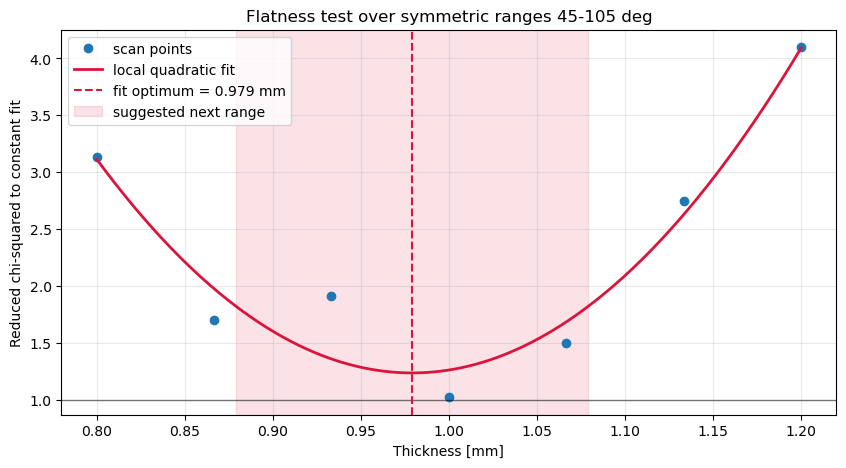

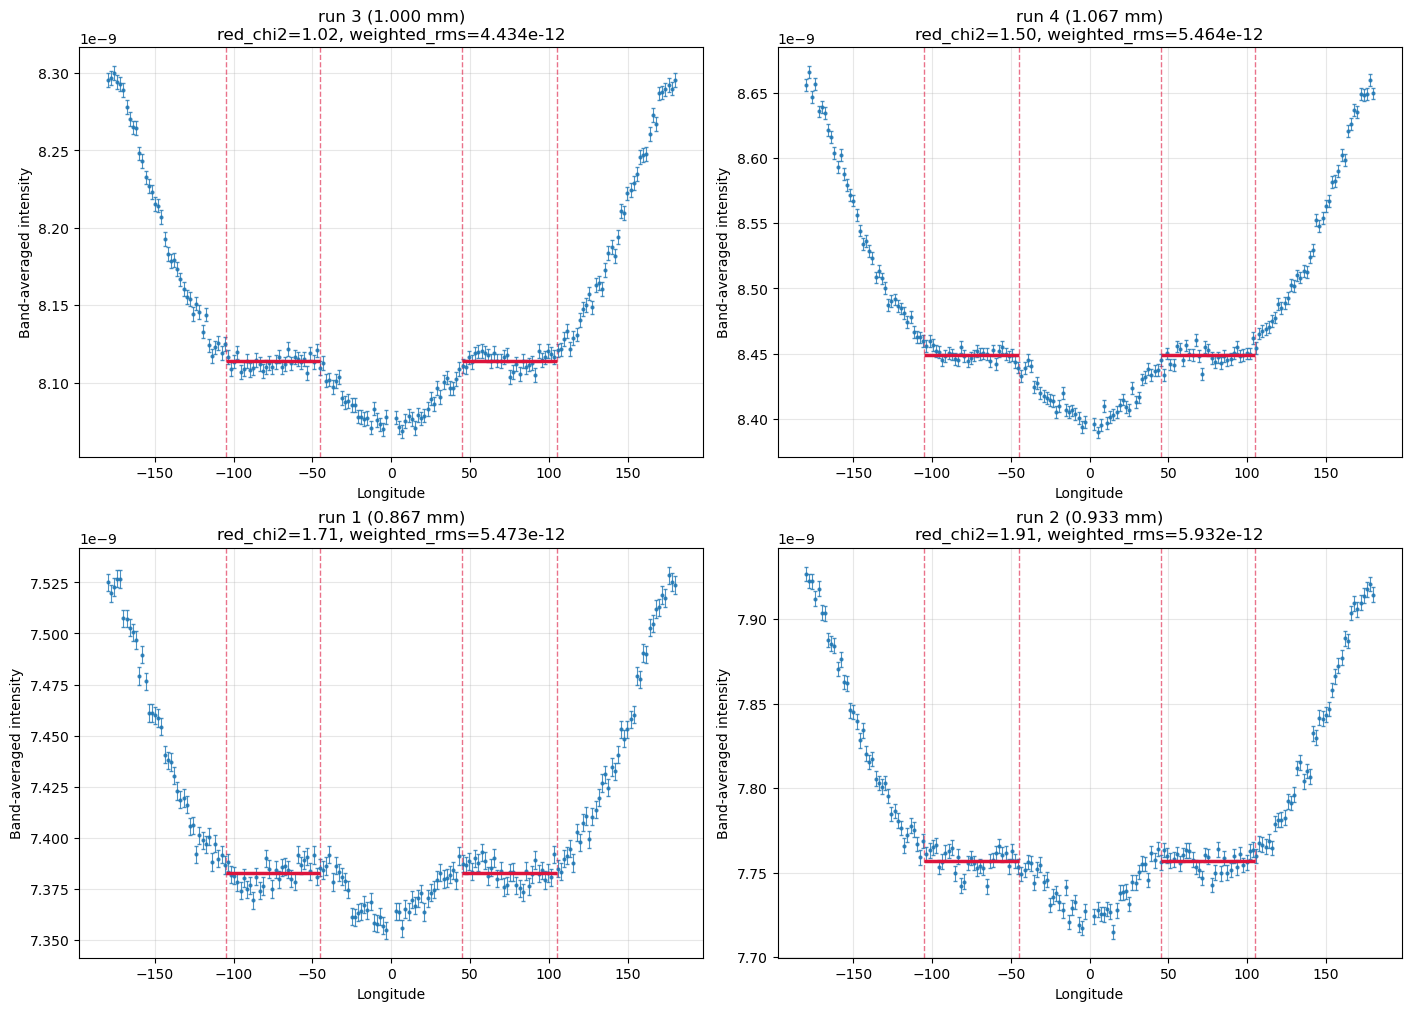

In [31]:
# Flatness test of thickness-scan equatorial cuts using symmetric side windows
fit_min_deg = 45.0
fit_max_deg = 105.0
scan_root = Path('/Users/christian/Documents/Study/bachelor_project/geometry_optimization/cylinder_instrument/0p8to1p2_r5mmh5cm_bathed_1e10')
run_indices = list(range(7))
thicknesses_mm = np.linspace(0.8, 1.2, len(run_indices))
results = []

for run_idx, thickness_mm in zip(run_indices, thicknesses_mm):
    sphere_mon = ms.load_data(str(scan_root / str(run_idx)))[0]
    meta = sphere_mon.metadata
    Hmc = np.array(sphere_mon.Intensity, copy=True)
    Hmc_err = np.array(sphere_mon.Error, copy=True)

    if hasattr(meta, 'dimension') and Hmc.shape == (meta.dimension[0], meta.dimension[1]):
        Hmc = Hmc.T
        Hmc_err = Hmc_err.T

    xmin, xmax, ymin, ymax = meta.limits
    lat_centers = np.linspace(
        ymin + 0.5 * (ymax - ymin) / Hmc.shape[0],
        ymax - 0.5 * (ymax - ymin) / Hmc.shape[0],
        Hmc.shape[0],
    )
    lon = np.linspace(xmin, xmax, Hmc.shape[1])
    cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
    safe_cos = np.where(np.abs(cos_correction) > 0, cos_correction, np.nan)

    Hmc_corrected = Hmc / safe_cos
    Hmc_err_corrected = Hmc_err / safe_cos
    pole_mask = np.abs(lat_centers) <= (90.0 - pole_cut_deg)
    Hmc_corrected = np.where(pole_mask[:, np.newaxis], Hmc_corrected, np.nan)
    Hmc_err_corrected = np.where(pole_mask[:, np.newaxis], Hmc_err_corrected, np.nan)

    Lon, Lat = np.meshgrid(lon, lat_centers)
    beam_mask = (np.abs(Lon) <= beam_lon_halfwidth_deg) & (np.abs(Lat) <= beam_lat_halfwidth_deg)
    full_mask = pole_mask[:, np.newaxis] & (~beam_mask)
    Hmc_masked = np.where(full_mask, Hmc_corrected, np.nan)
    Hmc_err_masked = np.where(full_mask, Hmc_err_corrected, np.nan)

    equator_band_mask = np.abs(lat_centers) <= equator_band_halfwidth
    equator_band = Hmc_masked[equator_band_mask, :]
    equator_band_err = Hmc_err_masked[equator_band_mask, :]

    equator_cut = np.nanmean(equator_band, axis=0)
    valid_counts = np.sum(~np.isnan(equator_band), axis=0)
    equator_cut_err = np.where(
        valid_counts > 0,
        np.sqrt(np.nansum(equator_band_err**2, axis=0)) / valid_counts,
        np.nan,
    )

    valid_cols = (valid_counts > 0) & (np.abs(lon) > beam_lon_halfwidth_deg)
    fit_mask = valid_cols & (((lon >= fit_min_deg) & (lon <= fit_max_deg)) | ((lon >= -fit_max_deg) & (lon <= -fit_min_deg)))

    x = lon[fit_mask]
    y = equator_cut[fit_mask]
    sigma = equator_cut_err[fit_mask]

    finite = np.isfinite(x) & np.isfinite(y) & np.isfinite(sigma) & (sigma > 0)
    x = x[finite]
    y = y[finite]
    sigma = sigma[finite]

    if len(x) < 2:
        continue

    weights = 1.0 / sigma**2
    const = np.sum(weights * y) / np.sum(weights)
    const_err = np.sqrt(1.0 / np.sum(weights))
    residuals = y - const
    chi2 = np.sum((residuals / sigma) ** 2)
    ndof = len(y) - 1
    red_chi2 = chi2 / ndof if ndof > 0 else np.nan
    weighted_rms = np.sqrt(np.sum(weights * residuals**2) / np.sum(weights))

    results.append({
        'run_idx': run_idx,
        'thickness_mm': thickness_mm,
        'const': const,
        'const_err': const_err,
        'weighted_rms': weighted_rms,
        'chi2': chi2,
        'red_chi2': red_chi2,
        'n_points': len(x),
        'fit_x': x,
        'fit_y': y,
        'fit_sigma': sigma,
        'lon_plot': lon[valid_cols],
        'equator_cut_plot': equator_cut[valid_cols],
        'equator_cut_err_plot': equator_cut_err[valid_cols],
    })

results = sorted(results, key=lambda r: abs(r['red_chi2'] - 1.0))

for r in results:
    print(
        f"run {r['run_idx']}: thickness={r['thickness_mm']:.3f} mm, "
        f"const={r['const']:.6e} +/- {r['const_err']:.6e}, "
        f"weighted_rms={r['weighted_rms']:.6e}, red_chi2={r['red_chi2']:.3f}, n={r['n_points']}"
    )

best = results[0]
print('')
print(
    f"Flattest in symmetric ranges [-{fit_max_deg:.0f}, -{fit_min_deg:.0f}] and [{fit_min_deg:.0f}, {fit_max_deg:.0f}] deg: "
    f"run {best['run_idx']} ({best['thickness_mm']:.3f} mm), red_chi2={best['red_chi2']:.3f}, weighted_rms={best['weighted_rms']:.6e}"
)

thickness_all = np.array([r['thickness_mm'] for r in results])
red_chi2_all = np.array([r['red_chi2'] for r in results])
order = np.argsort(thickness_all)
thickness_sorted = thickness_all[order]
red_chi2_sorted = red_chi2_all[order]

best_idx_sorted = int(np.nanargmin(red_chi2_sorted))
fit_window_half_width_mm = 0.25
local_fit_mask = np.abs(thickness_sorted - thickness_sorted[best_idx_sorted]) <= fit_window_half_width_mm

if np.sum(local_fit_mask) < 3:
    local_fit_mask = np.zeros_like(thickness_sorted, dtype=bool)
    lo = max(best_idx_sorted - 1, 0)
    hi = min(best_idx_sorted + 2, len(thickness_sorted))
    local_fit_mask[lo:hi] = True

quad_coeff = np.polyfit(thickness_sorted[local_fit_mask], red_chi2_sorted[local_fit_mask], 2)
a_quad, b_quad, c_quad = quad_coeff
best_thickness_fit = -b_quad / (2 * a_quad) if a_quad > 0 else np.nan
best_red_chi2_fit = np.polyval(quad_coeff, best_thickness_fit) if np.isfinite(best_thickness_fit) else np.nan

suggested_half_width_mm = 0.10
suggested_min = best_thickness_fit - suggested_half_width_mm
suggested_max = best_thickness_fit + suggested_half_width_mm
print(
    f"Quadratic local fit optimum: thickness={best_thickness_fit:.4f} mm, "
    f"red_chi2={best_red_chi2_fit:.3f}"
)
print(f"Suggested next scan range: {suggested_min:.3f} to {suggested_max:.3f} mm")

fit_x = np.linspace(np.nanmin(thickness_sorted[local_fit_mask]), np.nanmax(thickness_sorted[local_fit_mask]), 300)
fit_y = np.polyval(quad_coeff, fit_x)

plt.figure(figsize=(10, 5))
plt.plot(thickness_sorted, red_chi2_sorted, 'o', label='scan points')
plt.plot(fit_x, fit_y, color='crimson', lw=2, label='local quadratic fit')
plt.axhline(1.0, color='k', lw=1, alpha=0.5)
plt.axvline(best_thickness_fit, color='crimson', lw=1.5, ls='--', label=f'fit optimum = {best_thickness_fit:.3f} mm')
plt.axvspan(suggested_min, suggested_max, color='crimson', alpha=0.12, label='suggested next range')
plt.xlabel('Thickness [mm]')
plt.ylabel('Reduced chi-squared to constant fit')
plt.title(f'Flatness test over symmetric ranges {fit_min_deg:.0f}-{fit_max_deg:.0f} deg')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

best_four = results[:4]
fig, axs = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axs = axs.ravel()

for ax, r in zip(axs, best_four):
    ax.errorbar(
        r['lon_plot'],
        r['equator_cut_plot'],
        yerr=r['equator_cut_err_plot'],
        fmt='o',
        ms=2,
        elinewidth=0.8,
        capsize=1.5,
        alpha=0.8,
    )
    ax.hlines(r['const'], fit_min_deg, fit_max_deg, color='crimson', lw=2.5, zorder=5)
    ax.hlines(r['const'], -fit_max_deg, -fit_min_deg, color='crimson', lw=2.5, zorder=5)
    ax.axvline(fit_min_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    ax.axvline(fit_max_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    ax.axvline(-fit_min_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    ax.axvline(-fit_max_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Band-averaged intensity')
    ax.set_title(
        f"run {r['run_idx']} ({r['thickness_mm']:.3f} mm)\n"
        f"red_chi2={r['red_chi2']:.2f}, weighted_rms={r['weighted_rms']:.3e}"
    )
    ax.grid(True, alpha=0.3)

plt.show()


run 1: thickness=1.783 mm, const=3.756588e-08 +/- 5.471861e-13, weighted_rms=2.766904e-11, red_chi2=43.338, n=60, low_cut=3.570e-08
run 0: thickness=1.750 mm, const=3.724189e-08 +/- 5.450868e-13, weighted_rms=2.987721e-11, red_chi2=50.921, n=60, low_cut=3.539e-08
run 2: thickness=1.817 mm, const=3.787801e-08 +/- 5.491884e-13, weighted_rms=3.121784e-11, red_chi2=54.766, n=60, low_cut=3.600e-08
run 3: thickness=1.850 mm, const=3.818411e-08 +/- 5.511402e-13, weighted_rms=3.470747e-11, red_chi2=67.216, n=60, low_cut=3.629e-08

Flattest filtered run in symmetric ranges [-95, -35] and [35, 95] deg: run 1 (1.783 mm), red_chi2=43.338, weighted_rms=2.766904e-11


/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_43348/2232553087.py:46: RuntimeWarning: Mean of empty slice
  equator_cut = np.nanmean(equator_band_nonzero, axis=0)
/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_43348/2232553087.py:50: RuntimeWarning: invalid value encountered in divide
  np.sqrt(np.nansum(equator_band_err_nonzero**2, axis=0)) / valid_counts,


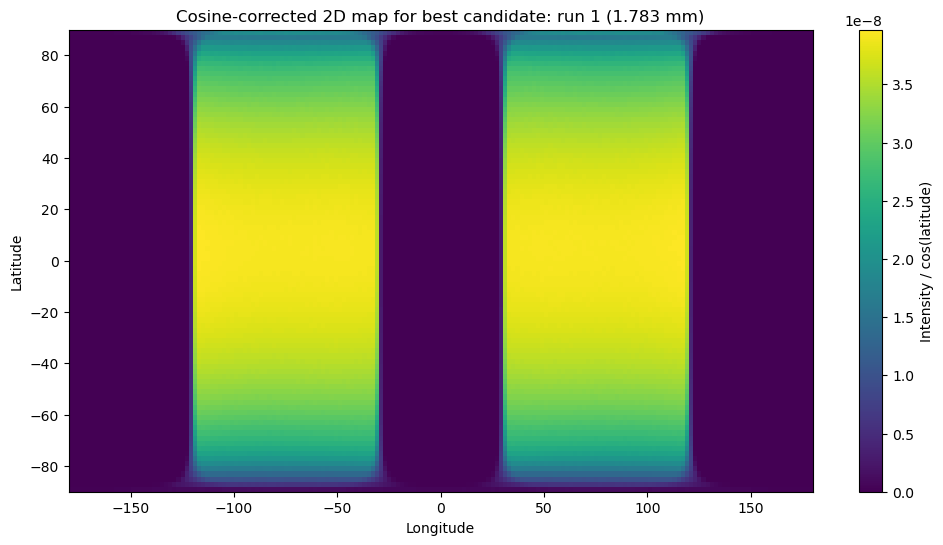

Quadratic local fit optimum: thickness=1.7799 mm, red_chi2=45.984
Suggested next scan range: 1.770 to 1.790 mm


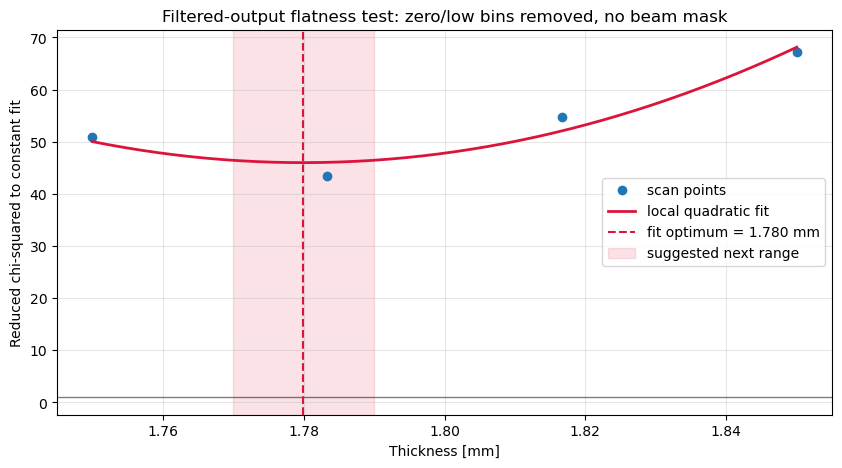

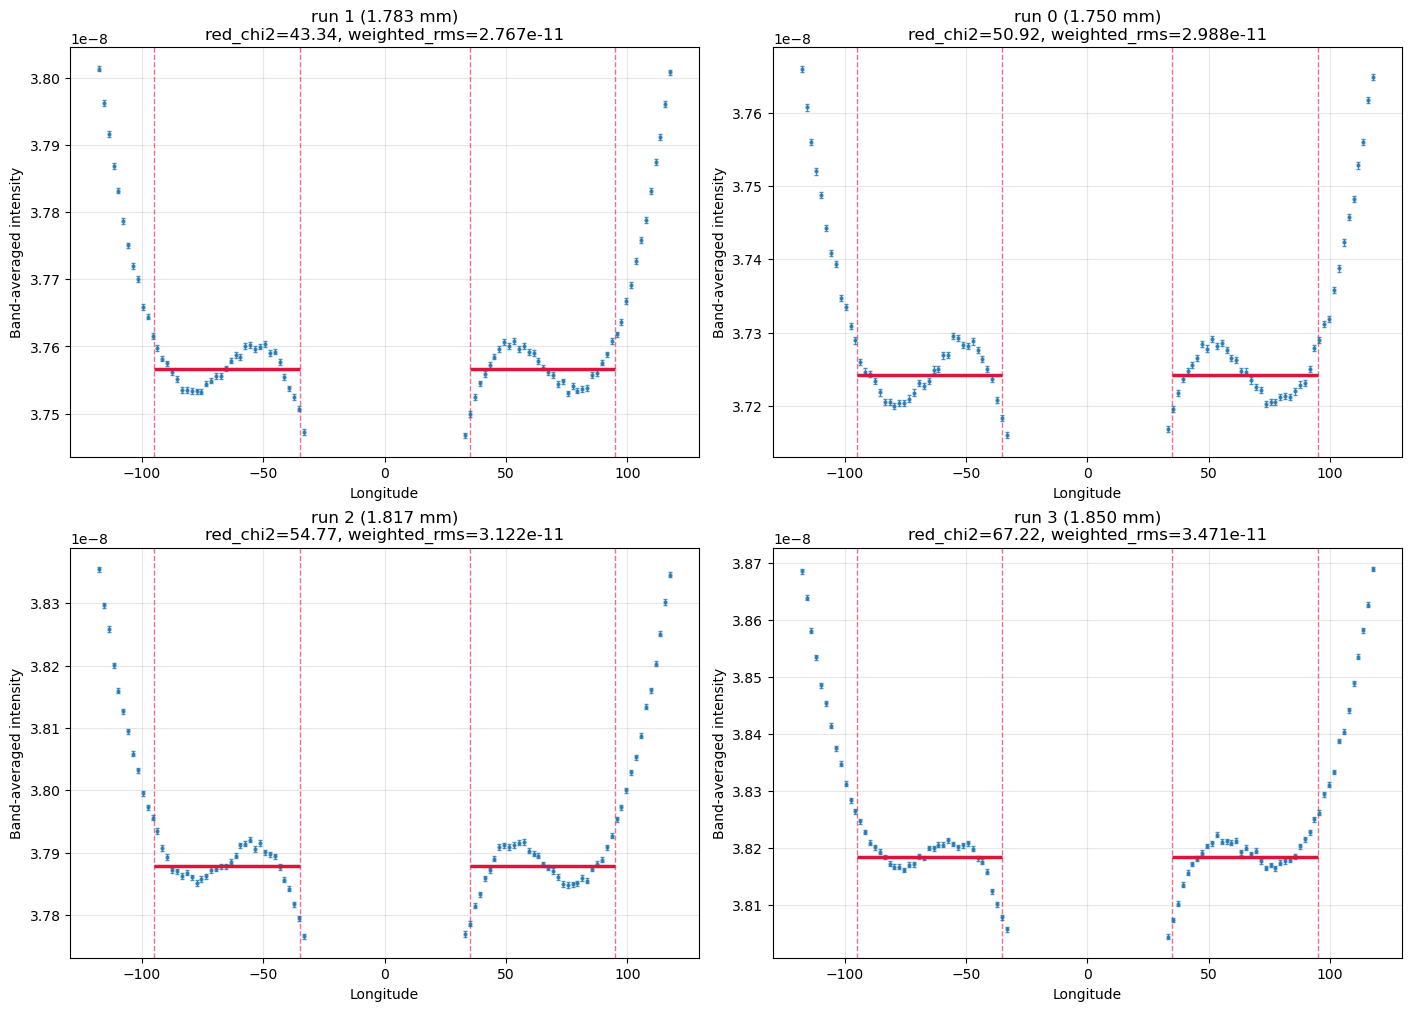

In [20]:
# Thickness estimation using McStas angular-filtered output.
# No beamstop mask and no pole cut are applied here.
# Zero bins and low edge outliers are removed before the flatness test.
fit_min_deg = 35.0
fit_max_deg = 95.0
scan_root = Path('/Users/christian/Documents/Study/bachelor_project/geometry_optimization/cylinder_instrument/1p75to1p85_1e11')
run_indices = list(range(4))
thicknesses_mm = np.linspace(1.75, 1.85, len(run_indices))
low_outlier_fraction = 0.95
fit_window_half_width_mm = 0.1
suggested_half_width_mm = 0.01
results_filtered = []

for run_idx, thickness_mm in zip(run_indices, thicknesses_mm):
    sphere_mon = ms.load_data(str(scan_root / str(run_idx)))[0]
    meta = sphere_mon.metadata
    Hmc = np.array(sphere_mon.Intensity, copy=True)
    Hmc_err = np.array(sphere_mon.Error, copy=True)

    if hasattr(meta, 'dimension') and Hmc.shape == (meta.dimension[0], meta.dimension[1]):
        Hmc = Hmc.T
        Hmc_err = Hmc_err.T

    xmin, xmax, ymin, ymax = meta.limits
    lat_centers = np.linspace(
        ymin + 0.5 * (ymax - ymin) / Hmc.shape[0],
        ymax - 0.5 * (ymax - ymin) / Hmc.shape[0],
        Hmc.shape[0],
    )
    lon = np.linspace(xmin, xmax, Hmc.shape[1])

    cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
    safe_cos = np.where(np.abs(cos_correction) > 0, cos_correction, np.nan)
    Hmc_corrected = Hmc / safe_cos
    Hmc_err_corrected = Hmc_err / safe_cos

    equator_band_mask = np.abs(lat_centers) <= equator_band_halfwidth
    equator_band = Hmc_corrected[equator_band_mask, :]
    equator_band_err = Hmc_err_corrected[equator_band_mask, :]

    # Remove zero bins produced by the McStas angular filter before averaging.
    nonzero_band = equator_band > 0
    equator_band_nonzero = np.where(nonzero_band, equator_band, np.nan)
    equator_band_err_nonzero = np.where(nonzero_band, equator_band_err, np.nan)

    equator_cut = np.nanmean(equator_band_nonzero, axis=0)
    valid_counts = np.sum(~np.isnan(equator_band_nonzero), axis=0)
    equator_cut_err = np.where(
        valid_counts > 0,
        np.sqrt(np.nansum(equator_band_err_nonzero**2, axis=0)) / valid_counts,
        np.nan,
    )

    # Remove low outlier columns caused by partially filled filter-edge bins.
    valid_cols = (valid_counts > 0) & np.isfinite(equator_cut) & (equator_cut > 0)
    low_outlier_threshold = low_outlier_fraction * np.nanmedian(equator_cut[valid_cols])
    valid_cols = valid_cols & (equator_cut >= low_outlier_threshold)

    fit_mask = valid_cols & (((lon >= fit_min_deg) & (lon <= fit_max_deg)) | ((lon >= -fit_max_deg) & (lon <= -fit_min_deg)))
    x = lon[fit_mask]
    y = equator_cut[fit_mask]
    sigma = equator_cut_err[fit_mask]

    finite = np.isfinite(x) & np.isfinite(y) & np.isfinite(sigma) & (sigma > 0)
    x = x[finite]
    y = y[finite]
    sigma = sigma[finite]

    if len(x) < 2:
        continue

    weights = 1.0 / sigma**2
    const = np.sum(weights * y) / np.sum(weights)
    const_err = np.sqrt(1.0 / np.sum(weights))
    residuals = y - const
    chi2 = np.sum((residuals / sigma) ** 2)
    ndof = len(y) - 1
    red_chi2 = chi2 / ndof if ndof > 0 else np.nan
    weighted_rms = np.sqrt(np.sum(weights * residuals**2) / np.sum(weights))

    results_filtered.append({
        'run_idx': run_idx,
        'thickness_mm': thickness_mm,
        'const': const,
        'const_err': const_err,
        'weighted_rms': weighted_rms,
        'chi2': chi2,
        'red_chi2': red_chi2,
        'n_points': len(x),
        'low_outlier_threshold': low_outlier_threshold,
        'map_corrected': Hmc_corrected,
        'map_extent': [xmin, xmax, ymin, ymax],
        'lon_plot': lon[valid_cols],
        'equator_cut_plot': equator_cut[valid_cols],
        'equator_cut_err_plot': equator_cut_err[valid_cols],
    })

results_filtered = sorted(results_filtered, key=lambda r: r['red_chi2'])

for r in results_filtered:
    print(
        f"run {r['run_idx']}: thickness={r['thickness_mm']:.3f} mm, "
        f"const={r['const']:.6e} +/- {r['const_err']:.6e}, "
        f"weighted_rms={r['weighted_rms']:.6e}, red_chi2={r['red_chi2']:.3f}, "
        f"n={r['n_points']}, low_cut={r['low_outlier_threshold']:.3e}"
    )

best = results_filtered[0]
print('')
print(
    f"Flattest filtered run in symmetric ranges [-{fit_max_deg:.0f}, -{fit_min_deg:.0f}] and [{fit_min_deg:.0f}, {fit_max_deg:.0f}] deg: "
    f"run {best['run_idx']} ({best['thickness_mm']:.3f} mm), red_chi2={best['red_chi2']:.3f}, weighted_rms={best['weighted_rms']:.6e}"
)

plt.figure(figsize=(12, 6))
plt.imshow(best['map_corrected'], extent=best['map_extent'], origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='Intensity / cos(latitude)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f"Cosine-corrected 2D map for best candidate: run {best['run_idx']} ({best['thickness_mm']:.3f} mm)")
plt.show()

thickness_all = np.array([r['thickness_mm'] for r in results_filtered])
red_chi2_all = np.array([r['red_chi2'] for r in results_filtered])
order = np.argsort(thickness_all)
thickness_sorted = thickness_all[order]
red_chi2_sorted = red_chi2_all[order]

best_idx_sorted = int(np.nanargmin(red_chi2_sorted))

local_fit_mask = np.abs(thickness_sorted - thickness_sorted[best_idx_sorted]) <= fit_window_half_width_mm

if np.sum(local_fit_mask) < 3:
    local_fit_mask = np.zeros_like(thickness_sorted, dtype=bool)
    lo = max(best_idx_sorted - 1, 0)
    hi = min(best_idx_sorted + 2, len(thickness_sorted))
    local_fit_mask[lo:hi] = True

quad_coeff = np.polyfit(thickness_sorted[local_fit_mask], red_chi2_sorted[local_fit_mask], 2)
a_quad, b_quad, c_quad = quad_coeff
best_thickness_fit = -b_quad / (2 * a_quad) if a_quad > 0 else np.nan
best_red_chi2_fit = np.polyval(quad_coeff, best_thickness_fit) if np.isfinite(best_thickness_fit) else np.nan


suggested_min = best_thickness_fit - suggested_half_width_mm
suggested_max = best_thickness_fit + suggested_half_width_mm
print(
    f"Quadratic local fit optimum: thickness={best_thickness_fit:.4f} mm, "
    f"red_chi2={best_red_chi2_fit:.3f}"
)
print(f"Suggested next scan range: {suggested_min:.3f} to {suggested_max:.3f} mm")

fit_x = np.linspace(np.nanmin(thickness_sorted[local_fit_mask]), np.nanmax(thickness_sorted[local_fit_mask]), 300)
fit_y = np.polyval(quad_coeff, fit_x)

plt.figure(figsize=(10, 5))
plt.plot(thickness_sorted, red_chi2_sorted, 'o', label='scan points')
plt.plot(fit_x, fit_y, color='crimson', lw=2, label='local quadratic fit')
plt.axhline(1.0, color='k', lw=1, alpha=0.5)
plt.axvline(best_thickness_fit, color='crimson', lw=1.5, ls='--', label=f'fit optimum = {best_thickness_fit:.3f} mm')
plt.axvspan(suggested_min, suggested_max, color='crimson', alpha=0.12, label='suggested next range')
plt.xlabel('Thickness [mm]')
plt.ylabel('Reduced chi-squared to constant fit')
plt.title('Filtered-output flatness test: zero/low bins removed, no beam mask')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

best_four = results_filtered[:4]
fig, axs = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axs = axs.ravel()

for ax, r in zip(axs, best_four):
    ax.errorbar(
        r['lon_plot'],
        r['equator_cut_plot'],
        yerr=r['equator_cut_err_plot'],
        fmt='o',
        ms=2,
        elinewidth=0.8,
        capsize=1.5,
        alpha=0.8,
    )
    ax.hlines(r['const'], fit_min_deg, fit_max_deg, color='crimson', lw=2.5, zorder=5)
    ax.hlines(r['const'], -fit_max_deg, -fit_min_deg, color='crimson', lw=2.5, zorder=5)
    ax.axvline(fit_min_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    ax.axvline(fit_max_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    ax.axvline(-fit_min_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    ax.axvline(-fit_max_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Band-averaged intensity')
    ax.set_title(
        f"run {r['run_idx']} ({r['thickness_mm']:.3f} mm)\n"
        f"red_chi2={r['red_chi2']:.2f}, weighted_rms={r['weighted_rms']:.3e}"
    )
    ax.grid(True, alpha=0.3)

plt.show()


Beam bathes full sample: best run 0 (1.000 mm), red_chi2=1.775, weighted_rms=5.837539e-12, n=60
Beam avoids lids: best run 0 (1.000 mm), red_chi2=2.117, weighted_rms=4.241414e-12, n=60


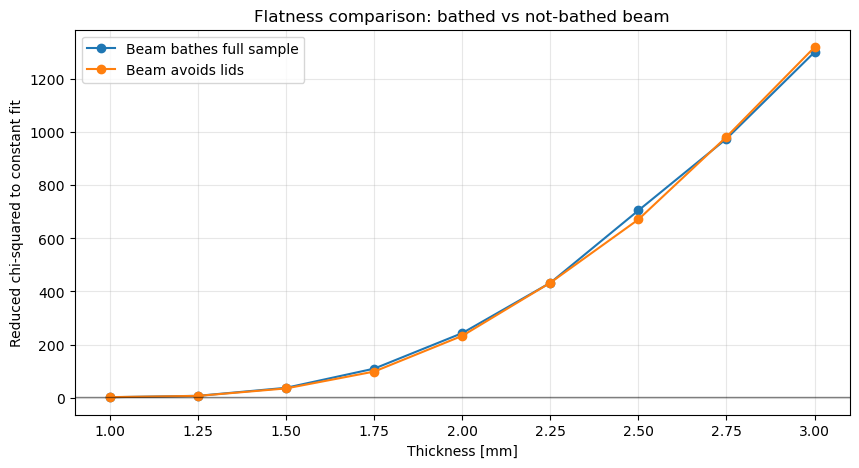

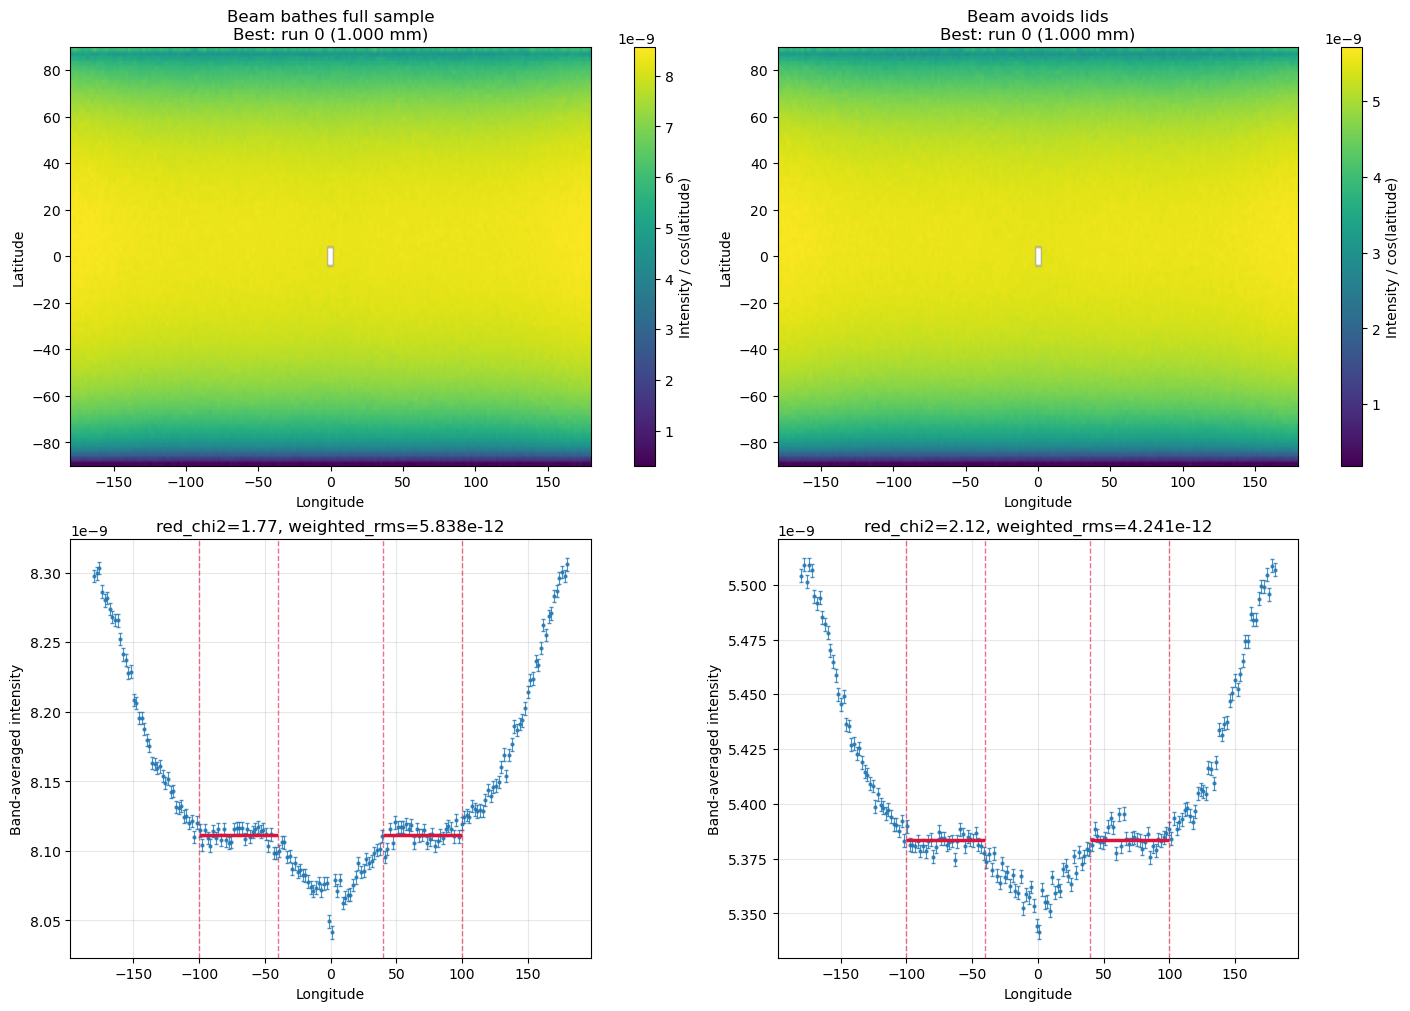

In [24]:
# Compare two thickness scans:
# 1) beam bathes the full sample, including lids
# 2) narrower beam, so the lids are not illuminated
# Uses cosine-corrected maps, beam-center masking, zero-bin removal, and low-outlier rejection.

fit_min_deg = 40.0
fit_max_deg = 100.0
equator_band_halfwidth_local = 50.0
beam_lon_halfwidth_deg_local = 2.0
beam_lat_halfwidth_deg_local = 4.0
low_outlier_fraction = 0.8

scan_configs = {
    'bathe': {
        'root': Path('/Users/christian/Documents/Study/bachelor_project/geometry_optimization/cylinder_instrument/1to3_r5mmh5cm_bathed_1e10'),
        'label': 'Beam bathes full sample',
    },
    'notbathed': {
        'root': Path('/Users/christian/Documents/Study/bachelor_project/geometry_optimization/cylinder_instrument/1to3_r5mmh5cm_notbathed_1e10'),
        'label': 'Beam avoids lids',
    },
}

run_indices = list(range(9))
thicknesses_mm = np.linspace(1.0, 3.0, len(run_indices))

def analyze_scan(scan_root):
    results = []

    for run_idx, thickness_mm in zip(run_indices, thicknesses_mm):
        sphere_mon = ms.load_data(str(scan_root / str(run_idx)))[0]
        meta = sphere_mon.metadata
        Hmc = np.array(sphere_mon.Intensity, copy=True)
        Hmc_err = np.array(sphere_mon.Error, copy=True)

        if hasattr(meta, 'dimension') and Hmc.shape == (meta.dimension[0], meta.dimension[1]):
            Hmc = Hmc.T
            Hmc_err = Hmc_err.T

        xmin, xmax, ymin, ymax = meta.limits
        extent = [xmin, xmax, ymin, ymax]
        lat_centers = np.linspace(
            ymin + 0.5 * (ymax - ymin) / Hmc.shape[0],
            ymax - 0.5 * (ymax - ymin) / Hmc.shape[0],
            Hmc.shape[0],
        )
        lon = np.linspace(xmin, xmax, Hmc.shape[1])

        cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
        safe_cos = np.where(np.abs(cos_correction) > 0, cos_correction, np.nan)
        Hmc_corrected = Hmc / safe_cos
        Hmc_err_corrected = Hmc_err / safe_cos

        Lon, Lat = np.meshgrid(lon, lat_centers)
        beam_center_mask = (
            (np.abs(Lon) <= beam_lon_halfwidth_deg_local) &
            (np.abs(Lat) <= beam_lat_halfwidth_deg_local)
        )
        Hmc_masked = np.where(~beam_center_mask, Hmc_corrected, np.nan)
        Hmc_err_masked = np.where(~beam_center_mask, Hmc_err_corrected, np.nan)

        equator_band_mask = np.abs(lat_centers) <= equator_band_halfwidth_local
        equator_band = Hmc_masked[equator_band_mask, :]
        equator_band_err = Hmc_err_masked[equator_band_mask, :]

        nonzero_band = equator_band > 0
        equator_band_nonzero = np.where(nonzero_band, equator_band, np.nan)
        equator_band_err_nonzero = np.where(nonzero_band, equator_band_err, np.nan)

        equator_cut = np.nanmean(equator_band_nonzero, axis=0)
        valid_counts = np.sum(~np.isnan(equator_band_nonzero), axis=0)
        equator_cut_err = np.where(
            valid_counts > 0,
            np.sqrt(np.nansum(equator_band_err_nonzero**2, axis=0)) / valid_counts,
            np.nan,
        )

        valid_cols = (valid_counts > 0) & np.isfinite(equator_cut) & (equator_cut > 0)
        low_outlier_threshold = low_outlier_fraction * np.nanmedian(equator_cut[valid_cols])
        valid_cols = valid_cols & (equator_cut >= low_outlier_threshold)

        fit_mask = valid_cols & (((lon >= fit_min_deg) & (lon <= fit_max_deg)) | ((lon >= -fit_max_deg) & (lon <= -fit_min_deg)))
        x = lon[fit_mask]
        y = equator_cut[fit_mask]
        sigma = equator_cut_err[fit_mask]

        finite = np.isfinite(x) & np.isfinite(y) & np.isfinite(sigma) & (sigma > 0)
        x = x[finite]
        y = y[finite]
        sigma = sigma[finite]

        if len(x) < 2:
            continue

        weights = 1.0 / sigma**2
        const = np.sum(weights * y) / np.sum(weights)
        const_err = np.sqrt(1.0 / np.sum(weights))
        residuals = y - const
        chi2 = np.sum((residuals / sigma) ** 2)
        ndof = len(y) - 1
        red_chi2 = chi2 / ndof if ndof > 0 else np.nan
        weighted_rms = np.sqrt(np.sum(weights * residuals**2) / np.sum(weights))

        results.append({
            'run_idx': run_idx,
            'thickness_mm': thickness_mm,
            'const': const,
            'const_err': const_err,
            'weighted_rms': weighted_rms,
            'red_chi2': red_chi2,
            'n_points': len(x),
            'map_corrected': Hmc_masked,
            'map_extent': extent,
            'lon_plot': lon[valid_cols],
            'equator_cut_plot': equator_cut[valid_cols],
            'equator_cut_err_plot': equator_cut_err[valid_cols],
        })

    return sorted(results, key=lambda r: r['red_chi2'])

analysis = {name: analyze_scan(cfg['root']) for name, cfg in scan_configs.items()}

for name, cfg in scan_configs.items():
    best = analysis[name][0]
    print(
        f"{cfg['label']}: best run {best['run_idx']} ({best['thickness_mm']:.3f} mm), "
        f"red_chi2={best['red_chi2']:.3f}, weighted_rms={best['weighted_rms']:.6e}, n={best['n_points']}"
    )

plt.figure(figsize=(10, 5))
for name, cfg in scan_configs.items():
    plt.plot(
        [r['thickness_mm'] for r in analysis[name]],
        [r['red_chi2'] for r in analysis[name]],
        'o-',
        label=cfg['label'],
    )
plt.axhline(1.0, color='k', lw=1, alpha=0.5)
plt.xlabel('Thickness [mm]')
plt.ylabel('Reduced chi-squared to constant fit')
plt.title('Flatness comparison: bathed vs not-bathed beam')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

fig, axs = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
for col, (name, cfg) in enumerate(scan_configs.items()):
    best = analysis[name][0]

    im = axs[0, col].imshow(best['map_corrected'], extent=best['map_extent'], origin='lower', aspect='auto', cmap='viridis')
    axs[0, col].set_xlabel('Longitude')
    axs[0, col].set_ylabel('Latitude')
    axs[0, col].set_title(f"{cfg['label']}\nBest: run {best['run_idx']} ({best['thickness_mm']:.3f} mm)")
    fig.colorbar(im, ax=axs[0, col], label='Intensity / cos(latitude)')

    axs[1, col].errorbar(
        best['lon_plot'],
        best['equator_cut_plot'],
        yerr=best['equator_cut_err_plot'],
        fmt='o',
        ms=2,
        elinewidth=0.8,
        capsize=1.5,
        alpha=0.8,
    )
    axs[1, col].hlines(best['const'], fit_min_deg, fit_max_deg, color='crimson', lw=2.5, zorder=5)
    axs[1, col].hlines(best['const'], -fit_max_deg, -fit_min_deg, color='crimson', lw=2.5, zorder=5)
    axs[1, col].axvline(fit_min_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    axs[1, col].axvline(fit_max_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    axs[1, col].axvline(-fit_min_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    axs[1, col].axvline(-fit_max_deg, color='crimson', lw=1.0, ls='--', alpha=0.6)
    axs[1, col].set_xlabel('Longitude')
    axs[1, col].set_ylabel('Band-averaged intensity')
    axs[1, col].set_title(f"red_chi2={best['red_chi2']:.2f}, weighted_rms={best['weighted_rms']:.3e}")
    axs[1, col].grid(True, alpha=0.3)

plt.show()


Best movable-window result: run 5 (0.750 mm), center=77.0 deg (offset +0.0 deg), red_chi2=1.435, weighted_rms=1.575e+02, n=60

Best monitor center for each thickness:
thickness=0.500 mm: center=87.0 deg (offset +10.0), red_chi2=1.493
thickness=0.550 mm: center=81.0 deg (offset +4.0), red_chi2=2.181
thickness=0.600 mm: center=85.0 deg (offset +8.0), red_chi2=1.476
thickness=0.650 mm: center=85.0 deg (offset +8.0), red_chi2=1.579
thickness=0.700 mm: center=81.0 deg (offset +4.0), red_chi2=1.803
thickness=0.750 mm: center=77.0 deg (offset +0.0), red_chi2=1.435
thickness=0.800 mm: center=77.0 deg (offset +0.0), red_chi2=2.531
thickness=0.850 mm: center=69.0 deg (offset -8.0), red_chi2=1.647
thickness=0.900 mm: center=71.0 deg (offset -6.0), red_chi2=2.278
thickness=0.950 mm: center=71.0 deg (offset -6.0), red_chi2=1.892
thickness=1.000 mm: center=73.0 deg (offset -4.0), red_chi2=1.851
thickness=1.050 mm: center=75.0 deg (offset -2.0), red_chi2=2.658
thickness=1.100 mm: center=73.0 deg (off

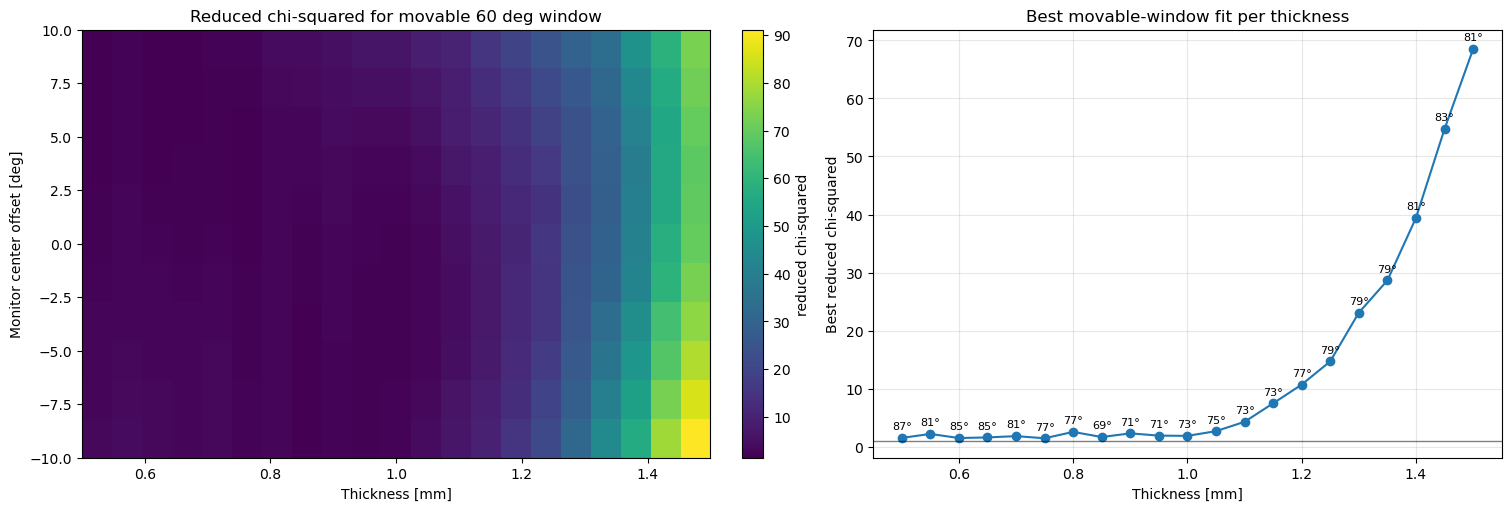

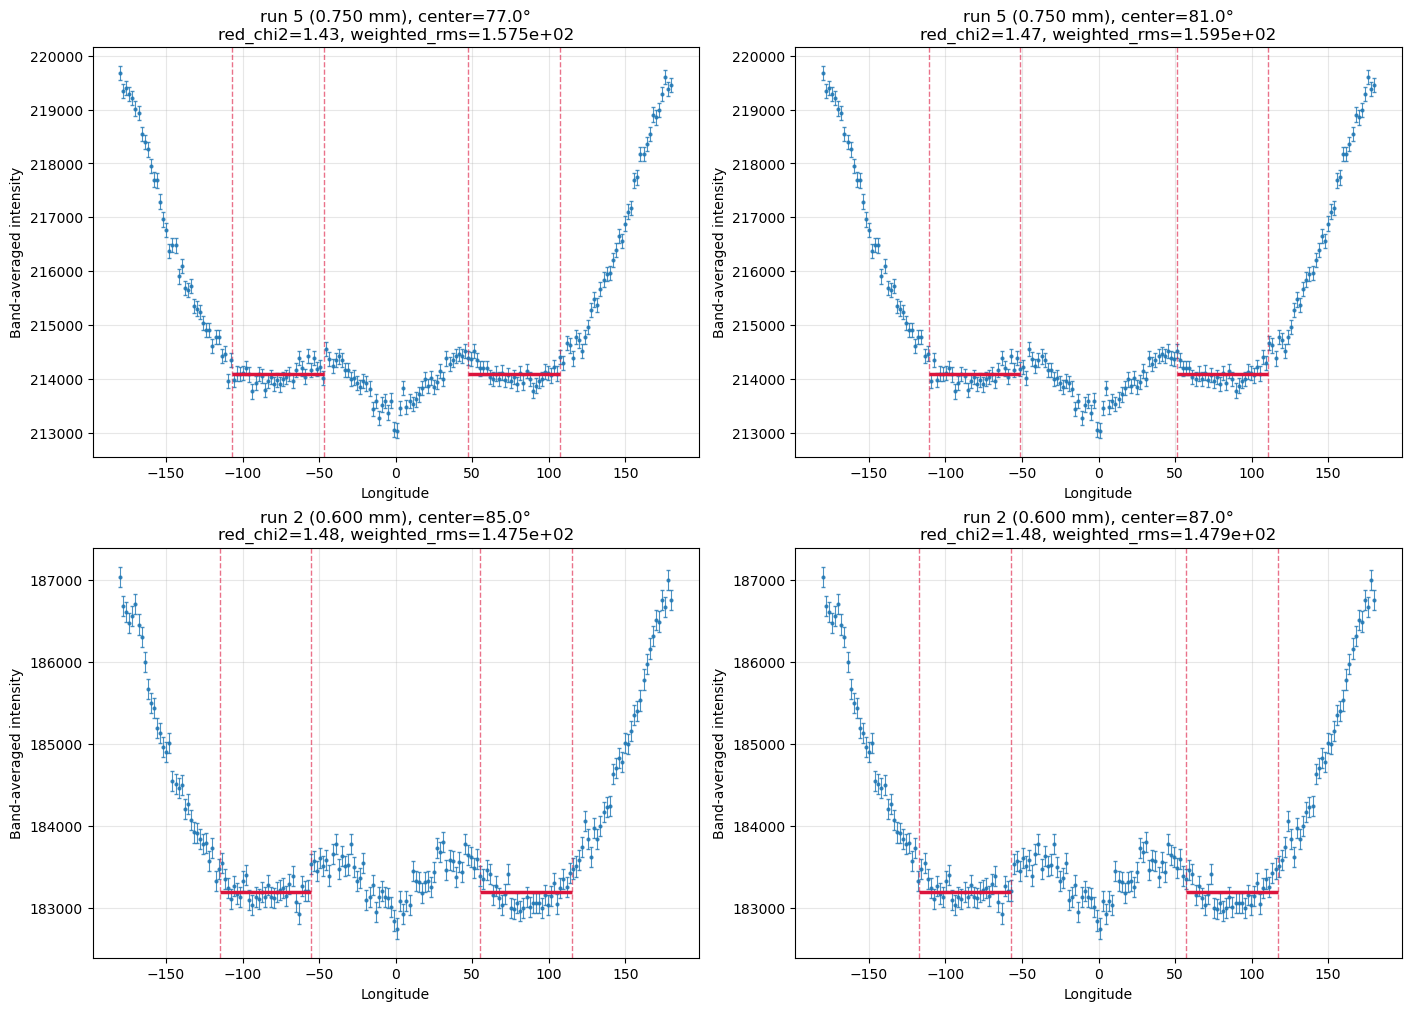

In [48]:
# Movable 60 degree detector-window flatness test.
# For each thickness, scan a few detector-center offsets and fit a constant
# in the two symmetric detector windows.
scan_root = Path('/Users/christian/Documents/Study/bachelor_project/geometry_optimization/cylinder_instrument/0p5to1p5_r5mmh5cm_bathed_nomono_1e10')
run_indices = list(range(21))
thicknesses_mm = np.linspace(0.5, 1.5, len(run_indices))

detector_window_width_deg = 60.0
nominal_detector_center_deg = 77.0
center_offsets_deg = np.arange(-10.0, 10.1, 2.0)
low_outlier_fraction = 0.8
equator_band_halfwidth_local = 50.0
beam_lon_halfwidth_deg_local = 2.0
beam_lat_halfwidth_deg_local = 4.0


def get_equator_cut(run_path):
    sphere_mon = ms.load_data(str(run_path))[0]
    meta = sphere_mon.metadata
    Hmc = np.array(sphere_mon.Intensity, copy=True)
    Hmc_err = np.array(sphere_mon.Error, copy=True)

    if hasattr(meta, 'dimension') and Hmc.shape == (meta.dimension[0], meta.dimension[1]):
        Hmc = Hmc.T
        Hmc_err = Hmc_err.T

    xmin, xmax, ymin, ymax = meta.limits
    lat_centers = np.linspace(
        ymin + 0.5 * (ymax - ymin) / Hmc.shape[0],
        ymax - 0.5 * (ymax - ymin) / Hmc.shape[0],
        Hmc.shape[0],
    )
    lon = np.linspace(xmin, xmax, Hmc.shape[1])

    cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
    safe_cos = np.where(np.abs(cos_correction) > 0, cos_correction, np.nan)
    Hmc_corrected = Hmc / safe_cos
    Hmc_err_corrected = Hmc_err / safe_cos

    Lon, Lat = np.meshgrid(lon, lat_centers)
    beam_center_mask = (
        (np.abs(Lon) <= beam_lon_halfwidth_deg_local) &
        (np.abs(Lat) <= beam_lat_halfwidth_deg_local)
    )
    Hmc_corrected = np.where(~beam_center_mask, Hmc_corrected, np.nan)
    Hmc_err_corrected = np.where(~beam_center_mask, Hmc_err_corrected, np.nan)

    equator_band_mask = np.abs(lat_centers) <= equator_band_halfwidth_local
    equator_band = Hmc_corrected[equator_band_mask, :]
    equator_band_err = Hmc_err_corrected[equator_band_mask, :]

    # Remove zero bins from McStas angular filtering before averaging.
    nonzero_band = equator_band > 0
    equator_band = np.where(nonzero_band, equator_band, np.nan)
    equator_band_err = np.where(nonzero_band, equator_band_err, np.nan)

    equator_cut = np.nanmean(equator_band, axis=0)
    valid_counts = np.sum(~np.isnan(equator_band), axis=0)
    equator_cut_err = np.where(
        valid_counts > 0,
        np.sqrt(np.nansum(equator_band_err**2, axis=0)) / valid_counts,
        np.nan,
    )

    valid_cols = (valid_counts > 0) & np.isfinite(equator_cut) & (equator_cut > 0)
    low_outlier_threshold = low_outlier_fraction * np.nanmedian(equator_cut[valid_cols])
    valid_cols = valid_cols & (equator_cut >= low_outlier_threshold)

    return lon, equator_cut, equator_cut_err, valid_cols


def constant_fit_score(lon, y, sigma, valid_cols, center_deg):
    half_width = detector_window_width_deg / 2.0
    pos_min = center_deg - half_width
    pos_max = center_deg + half_width
    neg_min = -pos_max
    neg_max = -pos_min

    fit_mask = valid_cols & (((lon >= pos_min) & (lon <= pos_max)) | ((lon >= neg_min) & (lon <= neg_max)))
    x_fit = lon[fit_mask]
    y_fit = y[fit_mask]
    sigma_fit = sigma[fit_mask]

    finite = np.isfinite(x_fit) & np.isfinite(y_fit) & np.isfinite(sigma_fit) & (sigma_fit > 0)
    x_fit = x_fit[finite]
    y_fit = y_fit[finite]
    sigma_fit = sigma_fit[finite]

    if len(x_fit) < 2:
        return None

    weights = 1.0 / sigma_fit**2
    const = np.sum(weights * y_fit) / np.sum(weights)
    const_err = np.sqrt(1.0 / np.sum(weights))
    residuals = y_fit - const
    chi2 = np.sum((residuals / sigma_fit) ** 2)
    ndof = len(y_fit) - 1
    red_chi2 = chi2 / ndof if ndof > 0 else np.nan
    weighted_rms = np.sqrt(np.sum(weights * residuals**2) / np.sum(weights))

    return {
        'center_deg': center_deg,
        'pos_min': pos_min,
        'pos_max': pos_max,
        'neg_min': neg_min,
        'neg_max': neg_max,
        'const': const,
        'const_err': const_err,
        'red_chi2': red_chi2,
        'weighted_rms': weighted_rms,
        'n_points': len(x_fit),
    }

all_results = []
best_by_thickness = []

for run_idx, thickness_mm in zip(run_indices, thicknesses_mm):
    lon, equator_cut, equator_cut_err, valid_cols = get_equator_cut(scan_root / str(run_idx))

    run_scores = []
    for offset_deg in center_offsets_deg:
        center_deg = nominal_detector_center_deg + offset_deg
        score = constant_fit_score(lon, equator_cut, equator_cut_err, valid_cols, center_deg)
        if score is None:
            continue
        score.update({
            'run_idx': run_idx,
            'thickness_mm': thickness_mm,
            'offset_deg': offset_deg,
            'lon_plot': lon[valid_cols],
            'equator_cut_plot': equator_cut[valid_cols],
            'equator_cut_err_plot': equator_cut_err[valid_cols],
        })
        run_scores.append(score)
        all_results.append(score)

    best_by_thickness.append(min(run_scores, key=lambda r: r['red_chi2']))

best_overall = min(all_results, key=lambda r: r['red_chi2'])
print(
    f"Best movable-window result: run {best_overall['run_idx']} "
    f"({best_overall['thickness_mm']:.3f} mm), center={best_overall['center_deg']:.1f} deg "
    f"(offset {best_overall['offset_deg']:+.1f} deg), red_chi2={best_overall['red_chi2']:.3f}, "
    f"weighted_rms={best_overall['weighted_rms']:.3e}, n={best_overall['n_points']}"
)

print("\nBest monitor center for each thickness:")
for r in best_by_thickness:
    print(
        f"thickness={r['thickness_mm']:.3f} mm: center={r['center_deg']:.1f} deg "
        f"(offset {r['offset_deg']:+.1f}), red_chi2={r['red_chi2']:.3f}"
    )

# Heatmap: red_chi2 as function of detector-center offset and thickness.
heatmap = np.full((len(center_offsets_deg), len(thicknesses_mm)), np.nan)
for r in all_results:
    i = np.where(center_offsets_deg == r['offset_deg'])[0][0]
    j = np.where(np.isclose(thicknesses_mm, r['thickness_mm']))[0][0]
    heatmap[i, j] = r['red_chi2']

fig, axs = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
im = axs[0].imshow(
    heatmap,
    origin='lower',
    aspect='auto',
    extent=[thicknesses_mm[0], thicknesses_mm[-1], center_offsets_deg[0], center_offsets_deg[-1]],
    cmap='viridis',
)
axs[0].set_xlabel('Thickness [mm]')
axs[0].set_ylabel('Monitor center offset [deg]')
axs[0].set_title('Reduced chi-squared for movable 60 deg window')
fig.colorbar(im, ax=axs[0], label='reduced chi-squared')

axs[1].plot(
    [r['thickness_mm'] for r in best_by_thickness],
    [r['red_chi2'] for r in best_by_thickness],
    'o-',
)
for r in best_by_thickness:
    axs[1].annotate(f"{r['center_deg']:.0f}°", (r['thickness_mm'], r['red_chi2']), textcoords='offset points', xytext=(0, 6), ha='center', fontsize=8)
axs[1].axhline(1.0, color='k', lw=1, alpha=0.5)
axs[1].set_xlabel('Thickness [mm]')
axs[1].set_ylabel('Best reduced chi-squared')
axs[1].set_title('Best movable-window fit per thickness')
axs[1].grid(True, alpha=0.3)
plt.show()

# Inspect best four movable-window candidates.
best_four = sorted(all_results, key=lambda r: r['red_chi2'])[:4]
fig, axs = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axs = axs.ravel()

for ax, r in zip(axs, best_four):
    ax.errorbar(
        r['lon_plot'],
        r['equator_cut_plot'],
        yerr=r['equator_cut_err_plot'],
        fmt='o',
        ms=2,
        elinewidth=0.8,
        capsize=1.5,
        alpha=0.8,
    )
    ax.hlines(r['const'], r['pos_min'], r['pos_max'], color='crimson', lw=2.5, zorder=5)
    ax.hlines(r['const'], r['neg_min'], r['neg_max'], color='crimson', lw=2.5, zorder=5)
    for xline in [r['pos_min'], r['pos_max'], r['neg_min'], r['neg_max']]:
        ax.axvline(xline, color='crimson', lw=1.0, ls='--', alpha=0.6)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Band-averaged intensity')
    ax.set_title(
        f"run {r['run_idx']} ({r['thickness_mm']:.3f} mm), center={r['center_deg']:.1f}°\n"
        f"red_chi2={r['red_chi2']:.2f}, weighted_rms={r['weighted_rms']:.3e}"
    )
    ax.grid(True, alpha=0.3)

plt.show()
